<a href="https://colab.research.google.com/github/sophiastmn/ML_Labs/blob/main/NeuralNetworks2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Final error: 5.126935738922748e-06
Training time: 0.3036928176879883s


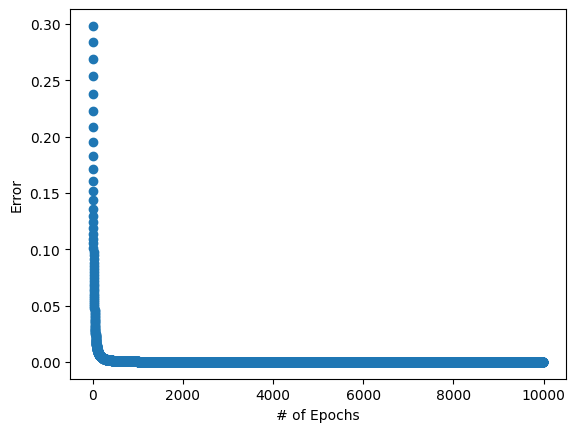

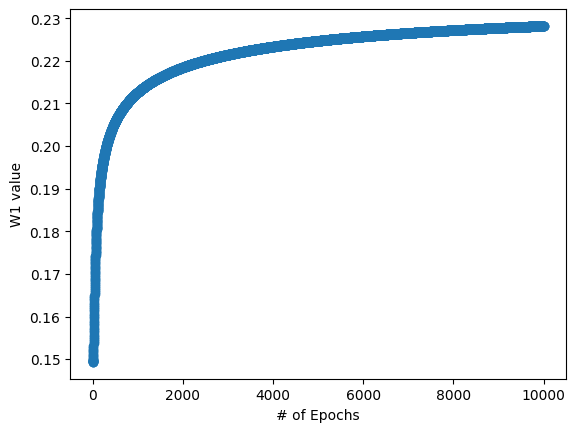

In [ ]:
############################################################# Problem #1 ###############################################################
import random;
import matplotlib.pyplot as plot;
import time;
import math;

class NeuralNetwork:
  perceptrons = [];

  def createPerceptrons(self, sizes, points, wholeSize):
    #creates empty perceptrons where size = [# perceptrons in input layer, # perceptrons in hidden layer #1, ... # perceptrons in hidden layer #n, # perceptrons in output layer]
    for k, layerSize in enumerate(sizes):
      perceptronLayer = [];
      for s in range(layerSize):
        singlePerceptron = Perceptron();
        singlePerceptron.setWeights([random.random() for i in range(wholeSize[k])]);
        singlePerceptron.setBias(random.random());
        perceptronLayer.append(singlePerceptron);
      self.perceptrons.append(perceptronLayer);

  def setWeights(self, weights):
    #takes in weights as [[weights for input layer], [weights for hidden layer 1], ..., [weights for hidden layer n], [weights for output layer]]
    for i, pLayer in enumerate(self.perceptrons):
      for j, perc in enumerate(pLayer):
        perc.setWeights(weights[i][j]);

  def setBias(self, bias):
    #takes in bias as [[biases for input layer], [biases for hidden layer 1], ..., [biases for hidden layer n], [biases for output layer]]
    for i, pLayer in enumerate(self.perceptrons):
      for j, perc in enumerate(pLayer):
        perc.setBias(bias[i][j]);

  def calculateOutputs(self, point):
    #calculate the "actual" values given input values
    intermittent = [[p for p in point]];

    #for each layer, calculate the intermittent outputs
    for layer in self.perceptrons:
      intermittent.append([perc.returnA(intermittent[-1]) for perc in layer]);

    #we need all of the intermittent values, so return them all
    return intermittent;

  def getWeights(self):
    #get the weights for all of the perceptrons
    weights = [];
    for layer in self.perceptrons:
      weightRow = [];
      for perc in layer:
        pWeights = perc.weights;
        for p in pWeights:
          weightRow.append(p);
      weights.append(weightRow);
    return weights;

  def getBias(self):
    #get the biases for all of the perceptrons
    bias = [];
    for layer in self.perceptrons:
      biasRow = [];
      for perc in layer:
        biasRow.append(perc.bias);
      bias.append(biasRow);
    return bias;

  def findPreErrors(self, aValues, trainingValues, point):
    #get the weights
    newWeights = self.getWeights();

    #find all of the errors
    preErrors = [[] for w in newWeights];
    #the last weights are readjusted with the formula: (a-t)(a)(1-a)
    currLen = len(aValues[-1]);
    preErrors[-1] = [(aValues[-1][i//currLen]-trainingValues[i//currLen])*aValues[-1][i//currLen]*(1-aValues[-1][i//currLen]) for i in range(len(newWeights[-1]))];
    #adjust the rest of the weights with the formula: prevError*weightToNode*a*(1-a)
    for i in range(len(newWeights)-1):
      currLen = len(aValues[-i-2]);
      preErrors[-i-2] = [sum([preE*newWeights[-i-1][k] for k, preE in enumerate(preErrors[-i-1]) if k%currLen == j//currLen])*
                         aValues[-i-2][j//currLen]*(1-aValues[-i-2][j//currLen]) for j in range(len(newWeights[-i-2]))];
    return preErrors;

  def adjustWeights(self, aValues, trainingValues, lv, point):
    #readjust the weights
    #get the weights
    newWeights = self.getWeights();

    #find all of the errors
    preError = self.findPreErrors(aValues, trainingValues, point);
    #actually readjust the weights
    newerWeights = [[lv*preError[i][j]*aValues[i][j//len(aValues[i])]*-1 + newWeights[i][j] for j in range(len(newWeights[i]))] for i in range(len(newWeights))];

    #change the format of the weights to readjust them
    transformedWeights = [];
    for index, layer in enumerate(newerWeights):
      layerWeights = [];
      for i in range(len(aValues[index+1])):
        start = i*len(aValues[index+1]);
        jump = len(aValues[index]);
        layerWeights.append(layer[start:start + jump]);
      transformedWeights.append(layerWeights);
    self.setWeights(transformedWeights);

  def adjustBias(self, aValues, trainingValues, lv, point):
    #readjust the bias
    #get the biases
    biases = self.getBias();

    #find all of the errors
    preError = self.findPreErrors(aValues, trainingValues, point);

    #actually readjust the bias
    newerBias = [[lv*preError[i][j]*-1 + biases[i][j] for j in range(len(biases[i]))] for i in range(len(biases))];
    self.setBias(newerBias);

class Perceptron:
  weights = [];
  bias = 0;

  def setBias(self, val):
    self.bias = val;
  def setWeights(self, newWeights):
    self.weights = newWeights;

  def adjustBias(self, errorRate, learningRate):
    biasNew = self.bias + errorRate*learningRate;
    if biasNew == self.bias:
      return False;
    self.bias = biasNew;
    return True;

  def adjustWeights(self, errorRate, learningRate, pt):
    weightsNew = [w + errorRate*learningRate*pt[i] for i, w in enumerate(self.weights)];
    if weightsNew == self.weights:
      return False;
    self.weights = weightsNew;
    return True;

  def returnA(self, point):
    return self.activationFunction(self.multiply(point) + self.bias);

  def multiply(self, point):
    return sum([self.weights[i] * point[i] for i in range(len(point))]);

  def activationFunction(self, value):
    return 1/(1+math.e**(-1*value));


def trainNetwork(nn, points, trainingValues, lv, maxEpochs):
  continue_question = True;
  #set the initial weights and bias
  nn.setWeights([[[0.15, 0.2], [0.25, 0.3]], [[0.4, 0.45], [0.5, 0.55]]]);
  nn.setBias([[0.35, 0.35], [0.6, 0.6]]);

  #create the data holders
  errorData = [];
  w1Data = [];

  #loop through each epoch and update data holders, check error to see if I should continue (if it's sufficiently low, stop early)
  for i in range(maxEpochs):
    error1 = epoch(nn, points, trainingValues, lv);
    errorData.append(error1);
    w1Data.append(nn.getWeights()[0][0]);
    if error1 < 0.0000000001:
      break;
  return errorData, w1Data;

def calculateError(training, actual):
    #calculate the mean squared error using the training and actual values
    sum = 0.0;
    for i in range(len(training)):
      sum += (training[i] - actual[i])**2;
    return sum/len(training);

def epoch(nn, points, trainingValues, lv):
  for i, p in enumerate(points):
    #run the forward pass on the point
    a = nn.calculateOutputs(p);
    #calculate the error at the point
    error = calculateError(trainingValues[i], a[-1]);

    #run the backward pass on the point
    wChange = nn.adjustWeights(a, trainingValues[i], lv, p);
    bChange = nn.adjustBias(a, trainingValues[i], lv, p);
  return error;


def main():
  random.seed(1880333);
  #generate a random line
  m = random.random()*3; #get a random slope between 0 and 3
  y = random.random()*6; #get a random line between 0 and 6
  learningVariable = 0.5; #set the learning variable
  maxEpochs = 10000;

  #initialize the points
  points = [[0.05, 0.10]];

  #give the training values
  trainingValues = [[0.01, 0.99]];

  #make a network
  nn = NeuralNetwork();
  nn.createPerceptrons([2, 2], points, [2, 2, 2]);

  #train the perceptron
  startTime = time.time();
  errorData, w1Data = trainNetwork(nn, points, trainingValues, learningVariable, maxEpochs);
  endTime = time.time();
  print(f"Final error: {errorData[-1]}");
  print(f"Training time: {endTime - startTime}s");

  #graph the error data
  plot.scatter([*range(maxEpochs)], errorData);
  plot.xlabel("# of Epochs");
  plot.ylabel("Error");
  plot.show();

  #graph the w1 data
  plot.scatter([*range(maxEpochs)], w1Data);
  plot.xlabel("# of Epochs");
  plot.ylabel("W1 value");
  plot.show();


if __name__ == "__main__":
  main();

In [ ]:
############################################################# Problem #2 ###############################################################
import random;
import matplotlib.pyplot as plot;
import time;
import math;
import csv;

class NeuralNetwork:
  #perceptrons = [];

  def __init__(self):
    self.perceptrons = [];

  def createPerceptrons(self, sizes, points, wholeSize):
    #creates empty perceptrons where size = [# perceptrons in input layer, # perceptrons in hidden layer #1, ... # perceptrons in hidden layer #n, # perceptrons in output layer]
    for k, layerSize in enumerate(sizes):
      perceptronLayer = [];
      for s in range(layerSize):
        singlePerceptron = Perceptron();
        singlePerceptron.setWeights([random.random()*2-1 for i in range(wholeSize[k])]);
        singlePerceptron.setBias(random.random()*1);
        perceptronLayer.append(singlePerceptron);
      self.perceptrons.append(perceptronLayer);

  def setWeights(self, weights):
    #takes in weights as [[weights for input layer], [weights for hidden layer 1], ..., [weights for hidden layer n], [weights for output layer]]
    for i, pLayer in enumerate(self.perceptrons):
      for j, perc in enumerate(pLayer):
        perc.setWeights(weights[i][j]);

  def setBias(self, bias):
    #takes in bias as [[biases for input layer], [biases for hidden layer 1], ..., [biases for hidden layer n], [biases for output layer]]
    for i, pLayer in enumerate(self.perceptrons):
      for j, perc in enumerate(pLayer):
        perc.setBias(bias[i][j]);

  def calculateOutputs(self, point):
    #calculate the "actual" values given input values
    intermittent = [[p for p in point]];

    #for each layer, calculate the intermittent outputs
    for layer in self.perceptrons:
      intermittent.append([perc.returnA(intermittent[-1]) for perc in layer]);

    #we need all of the intermittent values, so return them all
    return intermittent;

  def getWeights(self):
    #get the weights for all of the perceptrons
    weights = [];
    for layer in self.perceptrons:
      weightRow = [];
      for perc in layer:
        pWeights = perc.weights;
        for p in pWeights:
          weightRow.append(p);
      weights.append(weightRow);
    return weights;

  def getBias(self):
    #get the biases for all of the perceptrons
    bias = [];
    for layer in self.perceptrons:
      biasRow = [];
      for perc in layer:
        biasRow.append(perc.bias);
      bias.append(biasRow);
    return bias;

  def deriv(self, value):
    return value*(1-value);

  def findPreErrors(self, aValues, trainingValues, point):
    #get the weights
    oldWeights = self.getWeights();

    #print(f"Avals: {aValues[1:]}");
    #find all of the errors
    preErrors = [[] for w in oldWeights];
    #the last weights are readjusted with the formula: (a-t)(a)(1-a)
    currLen = len(aValues[-2]);
    for i in range(len(oldWeights[-1])):
      preErrors[-1].append((aValues[-1][i//currLen]-trainingValues[i//currLen])*self.deriv(aValues[-1][i//currLen]));

    #adjust the rest of the weights with the formula: prevError*weightToNode*a*(1-a)
    for i in range(1, len(oldWeights)):
      currLen = len(aValues[-i-2]);
      currLen2 = len(aValues[-i-1]);
      for j in range(len(oldWeights[-i-1])):
        summation = sum([preErrors[-i][k*currLen2+j//currLen]*oldWeights[-i][k*currLen2+j//currLen] for k in range(len(aValues[-i]))]);
        deriv = self.deriv(aValues[-i-1][j//currLen]);
        preErrors[-i-1].append(summation*deriv);
    #print(preErrors);
    #print(asdkajsdfkj);
    return preErrors;

  def adjustWeights(self, aValues, trainingValues, lv, point, preError):
    #readjust the weights
    #get the weights
    oldWeights = self.getWeights();


    #actually readjust the weights
    newerWeights = [[lv*preError[i][j]*aValues[i][j%len(aValues[i])]*-1 + oldWeights[i][j] for j in range(len(oldWeights[i]))] for i in range(len(oldWeights))];

    #print(newerWeights);
    #change the format of the weights to readjust them
    transformedWeights = [];
    for index, layer in enumerate(newerWeights):
      layerWeights = [];
      for i in range(len(aValues[index+1])):
        start = i*len(aValues[index]);
        jump = len(aValues[index]);
        layerWeights.append(layer[start:start + jump]);
      transformedWeights.append(layerWeights);

    self.setWeights(transformedWeights);

  def adjustBias(self, aValues, trainingValues, lv, point, preError):
    #readjust the bias
    #get the biases
    biases = self.getBias();

    #actually readjust the bias
    newerBias = [[lv*preError[i][j]*-1 + biases[i][j] for j in range(len(biases[i]))] for i in range(len(biases))];
    self.setBias(newerBias);

class Perceptron:
  #weights = [];
  #bias = 0;

  def __init__(self):
    self.weights = [];
    self.bias = 0;

  def setBias(self, val):
    self.bias = val;
  def setWeights(self, newWeights):
    self.weights = newWeights;

  def adjustBias(self, errorRate, learningRate):
    biasNew = self.bias + errorRate*learningRate;
    if biasNew == self.bias:
      return False;
    self.bias = biasNew;
    return True;

  def adjustWeights(self, errorRate, learningRate, pt):
    weightsNew = [w + errorRate*learningRate*pt[i] for i, w in enumerate(self.weights)];
    if weightsNew == self.weights:
      return False;
    self.weights = weightsNew;
    return True;

  def returnA(self, point):
    return self.activationFunction(self.multiply(point) + self.bias);

  def multiply(self, point):
    return sum([self.weights[i] * point[i] for i in range(len(point))]);

  def activationFunction(self, value):
    if value < -13:
      return 0;
    return 1/(1+math.e**(-1*value));


def trainNetwork(nn, points, trainingValues, lv, maxEpochs, testPoints, testValues):
  continue_question = True;
  errorData = [];
  w1Data = [];
  accuracyData = [];
  for i in range(maxEpochs):
    #run the training (epoch) and get the error for the last point in the epoch
    error1 = epoch(nn, points, trainingValues, lv);
    print(error1);
    #lv = 0.5;
    errorData.append(error1);

    #calculate the error from the test values
    #accuracy1 = calculateAccuracy(nn, testPoints, testValues);
    #accuracyData.append(accuracy1);
    #print(f"Accuracy: {accuracy1}");
    print(f"Accuracy2: {calculateAccuracy(nn, points[:100], trainingValues)}");

    #get the weight over epoch data
    w1Data.append(nn.getWeights()[0][0]);
    if error1 < 0.0000000001:
      break;
  return errorData, w1Data;

def calculateAccuracy(nn, points, values):
  totalCorrect = 0;
  total = 0;
  #for each point
  for i, p in enumerate(points):
    #calculate the output
    a = nn.calculateOutputs(p);

    #calculate the predicted value
    predicted = determineValue(a[-1]);
    value = determineValue(values[i]);

    #if correct, add 1 to totalCorrect\
    if predicted == value: totalCorrect += 1;
    total+= 1;
  return totalCorrect/(total+0.0);

def determineValue(line):
  #determine the predicted value from the line
  max1 = max(line);
  #print(f"max: {max1}, index: {line.index(max1)}");
  returnable = line.index(max1);
  return returnable;

def calculateError(training, actual):
    #calculate the mean squared error using the training and actual values
    sum = 0.0;
    for i in range(len(training)):
      sum += (training[i] - actual[i])**2;
    #print(actual);
    return sum/len(training);

def epoch(nn, points, trainingValues, lv):
  for i, p in enumerate(points[:100]):
    #run the forward pass on the point
    a = nn.calculateOutputs(p);

    #calculate the error at the point
    error = calculateError(trainingValues[i], a[-1]);
    #print(error);

    #run the backward pass on the point
    preError = nn.findPreErrors(a, trainingValues[i], p);
    wChange = nn.adjustWeights(a, trainingValues[i], lv, p, preError);
    bChange = nn.adjustBias(a, trainingValues[i], lv, p, preError);
    if lv > 10:
      lv = lv // 1000;
  return error;

def readData(filename):
  #process the data
  returnable = [];
  file = open(filename, "r");
  csv_reader = csv.reader(file);
  for row in csv_reader:
    returnable.append([*row]);
  file.close();

  #split the data into the labels and data
  if filename == "train.csv":
    returnable = returnable[1:];
  data = [];
  labels = [];
  try:
    data = [[float(r)/255 for r in retur[1:]] for retur in returnable];
    labels = [int(retur[0]) for retur in returnable];
  except:
    data = [[float(r)/255 for r in retur[1:]] for retur in returnable[1:]];
    labels = [int(retur[0]) for retur in returnable[1:]];
  for i in range(len(labels)):
    temp = [0]*10;
    temp[labels[i]] = 1;
    labels[i] = temp;
  return data, labels;


def main():
  random.seed(1880333);
  learningVariable = 0.5; #set the learning variable
  maxEpochs = 100000;

  #initialize the points, give the training values
  points, trainingValues = readData("train.csv");

  #get the testing points
  testPoints, testValues = readData("test.csv");

  #make a network
  nn = NeuralNetwork();
  nn.createPerceptrons([50, 10], points, [784, 50, 10]);


  #initialize the points
  #points = [[0.05, 0.10]];

  #give the training values
  #trainingValues = [[0.01, 0.99]];

  #make a network
  #nn = NeuralNetwork();
  #nn.createPerceptrons([3, 2], points, [2, 3, 2]);

  #train the perceptron
  startTime = time.time();
  errorData, w1Data = trainNetwork(nn, points, trainingValues, learningVariable, maxEpochs, testPoints, testValues);
  endTime = time.time();
  '''
  print(f"Final error: {errorData[-1]}");
  print(f"Training time: {endTime - startTime}s");

  #graph the error data
  plot.scatter([*range(maxEpochs)], errorData);
  plot.xlabel("# of Epochs");
  plot.ylabel("Error");
  plot.show();

  #graph the w1 data
  plot.scatter([*range(maxEpochs)], w1Data);
  plot.xlabel("# of Epochs");
  plot.ylabel("W1 value");
  plot.show();'''


if __name__ == "__main__":
  main();

0.1304591408631975
Accuracy2: 0.41
0.12738447358409857
Accuracy2: 0.49


In [64]:
################################## test ###########################################################
import random;
import matplotlib.pyplot as plot;
import time;
import math;

class NeuralNetwork:
  perceptrons = [];

  def createPerceptrons(self, sizes, points, wholeSize):
    #creates empty perceptrons where size = [# perceptrons in input layer, # perceptrons in hidden layer #1, ... # perceptrons in hidden layer #n, # perceptrons in output layer]
    for k, layerSize in enumerate(sizes):
      perceptronLayer = [];
      for s in range(layerSize):
        singlePerceptron = Perceptron();
        singlePerceptron.setWeights([random.random()*2-1 for i in range(wholeSize[k])]);
        singlePerceptron.setBias(random.random());
        perceptronLayer.append(singlePerceptron);
      self.perceptrons.append(perceptronLayer);

  def setWeights(self, weights):
    #takes in weights as [[weights for input layer], [weights for hidden layer 1], ..., [weights for hidden layer n], [weights for output layer]]
    for i, pLayer in enumerate(self.perceptrons):
      for j, perc in enumerate(pLayer):
        perc.setWeights(weights[i][j]);

  def setBias(self, bias):
    #takes in bias as [[biases for input layer], [biases for hidden layer 1], ..., [biases for hidden layer n], [biases for output layer]]
    for i, pLayer in enumerate(self.perceptrons):
      for j, perc in enumerate(pLayer):
        perc.setBias(bias[i][j]);

  def calculateOutputs(self, point):
    #calculate the "actual" values given input values
    intermittent = [[p for p in point]];

    #for each layer, calculate the intermittent outputs
    for layer in self.perceptrons:
      intermittent.append([perc.returnA(intermittent[-1]) for perc in layer]);

    #we need all of the intermittent values, so return them all
    return intermittent;

  def getWeights(self):
    #get the weights for all of the perceptrons
    weights = [];
    for layer in self.perceptrons:
      weightRow = [];
      for perc in layer:
        pWeights = perc.weights;
        for p in pWeights:
          weightRow.append(p);
      weights.append(weightRow);
    return weights;

  def getBias(self):
    #get the biases for all of the perceptrons
    bias = [];
    for layer in self.perceptrons:
      biasRow = [];
      for perc in layer:
        biasRow.append(perc.bias);
      bias.append(biasRow);
    return bias;

  def getDeriv(self, value):
    return value*(1-value);

  def findPreErrors(self, aValues, trainingValues, point):
    #get the weights
    oldWeights = self.getWeights();

    preErrors = [[] for w in oldWeights];

    #adjust the first level: (a-t)*(a)*(1-a)
    currLen = len(aValues[-1]);
    prevLen = len(aValues[-2]);
    preErrors[-1] = [(aValues[-1][i//prevLen]-trainingValues[i//prevLen])*self.getDeriv(aValues[-1][i//prevLen])
     for i in range(len(oldWeights[-1]))];

    #adjust the subsequent levels: sum(weights*previousNode's error)*a*(1-a)
    for k in range(1, len(oldWeights)):
      futuLen = len(aValues[-k]);
      currLen = len(aValues[-k-1]);
      prevLen = len(aValues[-k-2]);
      #print(f"{prevLen}, {currLen}, {futuLen}");
      #print([[preErrors[-k][j*currLen+i//prevLen] for j in range(futuLen)] for i in range(len(oldWeights[-k-1]))]);
      preErrors[-k-1] = [sum([preErrors[-k][j*currLen+i//prevLen]*oldWeights[-k][j*currLen+i//prevLen] for j in range(futuLen)])
          *self.getDeriv(aValues[-k-1][i//prevLen]) for i in range(len(oldWeights[-k-1]))];
    '''print(f"Preerrors -1: {preErrors[-1]}");
    print(f"Preerrors -2: {preErrors[-2]}");
    print(f"Avalues 0: {aValues[0]}");
    print(f"Avalues 1: {aValues[1]}");
    print(f"Avaules 2: {aValues[2]}");'''
    return preErrors;

  def adjustWeights(self, aValues, trainingValues, lv, point):
    #readjust the weights
    #get the weights
    newWeights = self.getWeights();

    #find all of the errors
    preError = self.findPreErrors(aValues, trainingValues, point);
    #actually readjust the weights
    print(preError);
    newerWeights = [[newWeights[i][j]-preError[i][j]*lv*aValues[i][j%len(aValues[i])] for j in range(len(newWeights[i]))] for i in range(len(newWeights))];
    #change the format of the weights to readjust them
    transformedWeights = [];
    for index, layer in enumerate(newerWeights):
      layerWeights = [];
      for i in range(len(aValues[index+1])):
        start = i*len(aValues[index]);
        jump = len(aValues[index]);
        layerWeights.append(layer[start:start + jump]);
      transformedWeights.append(layerWeights);
    print(f"Transformed: {transformedWeights}");
    self.setWeights(transformedWeights);

  def adjustBias(self, aValues, trainingValues, lv, point):
    #readjust the bias
    #get the biases
    biases = self.getBias();

    #find all of the errors
    preError = self.findPreErrors(aValues, trainingValues, point);

    #actually readjust the bias
    newerBias = [[lv*preError[i][j]*-1 + biases[i][j] for j in range(len(biases[i]))] for i in range(len(biases))];
    self.setBias(newerBias);

class Perceptron:
  weights = [];
  bias = 0;

  def setBias(self, val):
    self.bias = val;
  def setWeights(self, newWeights):
    self.weights = newWeights;

  def adjustBias(self, errorRate, learningRate):
    biasNew = self.bias + errorRate*learningRate;
    if biasNew == self.bias:
      return False;
    self.bias = biasNew;
    return True;

  def adjustWeights(self, errorRate, learningRate, pt):
    weightsNew = [w + errorRate*learningRate*pt[i] for i, w in enumerate(self.weights)];
    if weightsNew == self.weights:
      return False;
    self.weights = weightsNew;
    return True;

  def returnA(self, point):
    return self.activationFunction(self.multiply(point) + self.bias);

  def multiply(self, point):
    return sum([self.weights[i] * point[i] for i in range(len(point))]);

  def activationFunction(self, value):
    return 1/(1+math.e**(-1*value));


def trainNetwork(nn, points, trainingValues, lv, maxEpochs):
  continue_question = True;

  #create the data holders
  errorData = [];
  w1Data = [];
  #loop through each epoch and update data holders, check error to see if I should continue (if it's sufficiently low, stop early)
  for i in range(maxEpochs):
    error1 = epoch(nn, points, trainingValues, lv);
    print(error1);
    errorData.append(error1);
    w1Data.append(nn.getWeights()[0][0]);
    if error1 < 0.0000000001:
      break;
  return errorData, w1Data;

def calculateError(training, actual):
    #calculate the mean squared error using the training and actual values
    sum = 0.0;
    for i in range(len(training)):
      sum += (training[i] - actual[i])**2;
    return sum/len(training);

def epoch(nn, points, trainingValues, lv):
  for i, p in enumerate(points):
    #run the forward pass on the point
    a = nn.calculateOutputs(p);
    #calculate the error at the point
    error = calculateError(trainingValues[i], a[-1]);

    #run the backward pass on the point
    wChange = nn.adjustWeights(a, trainingValues[i], lv, p);
    bChange = nn.adjustBias(a, trainingValues[i], lv, p);
  return error;


def readData(filename):
  #process the data
  returnable = [];
  file = open(filename, "r");
  csv_reader = csv.reader(file);
  for row in csv_reader:
    returnable.append([*row]);
  file.close();

  #split the data into the labels and data
  if filename == "train.csv":
    returnable = returnable[1:];
  data = [];
  labels = [];
  try:
    data = [[float(r)/255 for r in retur[1:]] for retur in returnable];
    labels = [int(retur[0]) for retur in returnable];
  except:
    data = [[float(r)/255 for r in retur[1:]] for retur in returnable[1:]];
    labels = [int(retur[0]) for retur in returnable[1:]];
  for i in range(len(labels)):
    temp = [0]*10;
    temp[labels[i]] = 1;
    labels[i] = temp;
  return data, labels;


def main():
  random.seed(1880333);
  learningVariable = 0.5; #set the learning variable
  maxEpochs = 100;

  #initialize the points, give the training values
  #points, trainingValues = readData("train.csv");

  #get the testing points
  #testPoints, testValues = readData("test.csv");
  #testValues = [determineValue(t) for t in testValues];

  points = [[1.5, 2.5, 3.5], [4.5, 5.5, 6.5]];
  trainingValues = [[1.2, 2.3], [3.4, 4.5]];
  #make a network
  nn = NeuralNetwork();
  nn.createPerceptrons([4, 2], points, [3, 4, 2]);

  #train the perceptron
  startTime = time.time();
  errorData, w1Data = trainNetwork(nn, points, trainingValues, learningVariable, maxEpochs);
  endTime = time.time();
  print(f"Final error: {errorData[-1]}");
  print(f"Training time: {endTime - startTime}s");

  #graph the error data
  '''plot.scatter([*range(maxEpochs)], errorData);
  plot.xlabel("# of Epochs");
  plot.ylabel("Error");
  plot.show();

  #graph the w1 data
  plot.scatter([*range(maxEpochs)], w1Data);
  plot.xlabel("# of Epochs");
  plot.ylabel("W1 value");
  plot.show();'''


if __name__ == "__main__":
  main();

[[0.007712707890066116, 0.007712707890066116, 0.007712707890066116, 0.022007103925996918, 0.022007103925996918, 0.022007103925996918, 0.00828162957313631, 0.00828162957313631, 0.00828162957313631, -0.06275052965457291, -0.06275052965457291, -0.06275052965457291], [-0.1105630382149554, -0.1105630382149554, -0.1105630382149554, -0.1105630382149554, -0.4582017971845182, -0.4582017971845182, -0.4582017971845182, -0.4582017971845182]]
Transformed: [[[0.48816297252818186, -0.9748505849287397, -0.7871321256052483], [0.027576918457645178, -0.14311195649924366, -0.8311995572299451], [-0.4362395974806508, 0.24365004585234573, 0.8599373921259645], [-0.8911577505087702, -0.27538787820874006, 0.380293098471492]], [[0.3862784457480996, 0.018714185100748668, 0.2549872187423306, -0.2520116240284534], [-0.7252081688921553, -0.9067353789056846, -0.2957004060560471, 0.9158947829718512]]]
[[0.00029016788894303515, 0.00029016788894303515, 0.00029016788894303515, 0.0024378434877229053, 0.0024378434877229053